In [ ]:
# =====================================================
# FIX COLAB NUMPY + SKLEARN COMPATIBILITY
# =====================================================

!pip uninstall -y numpy scipy scikit-learn imbalanced-learn >/dev/null 2>&1

# Install versions that are KNOWN to work together
!pip install -q numpy==1.26.4
!pip install -q scipy==1.11.4
!pip install -q scikit-learn==1.4.2
!pip install -q imbalanced-learn==0.12.3

# Verify versions
import numpy as np
import sklearn
import scipy
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("sklearn:", sklearn.__version__)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spreg 1.8.4 requires scikit-learn>=0.22, which is not installed.
spreg 1.8.4 requires scipy>=0.11, which is not installed.
flax 0.10.7 requires jax>=0.6.0, which is not installed.
flax 0.10.7 requires tensorstore, which is not installed.
pytensor 2.35.1 requires scipy<2,>=1, which is not installed.
arviz 0.22.0 requires scipy>=1.11.0, which is not installed.
esda 2.8.0 requires scikit-learn>=1.4, which is not installed.
esda 2.8.0 requires scipy>=1.12, which is not installed.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, which is not installed.
umap-learn 0.5.9.post2 requires scipy>=1.3.1, which is not installed.
pymc 5.26.1 requires scipy>=1.4.1, which is not installed.
clarabel 0.11.1 requires scipy, which is not installed.
cuml-cu12 25.10.0 requires scikit-learn>=1.4, which is not installed.
cuml-cu12 25.1

In [ ]:

!pip uninstall -y jax jaxlib ml-dtypes ml_dtypes tensorstore dopamine-rl >/dev/null 2>&1 || echo "Some removals may not be needed"

!pip install --force-reinstall -q "tensorflow==2.19.0"
!pip install -q pyarrow fastparquet imbalanced-learn scikit-learn pandas numpy joblib

#Imports (after installs)
import tensorflow as tf
print("TensorFlow:", tf.__version__)

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from google.colab import files
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score
from imblearn.over_sampling import BorderlineSMOTE
from tensorflow.keras import layers, models

#Upload parquet files
print("Upload 'UNSW_NB15_training-set.parquet' (required). Optionally upload 'UNSW_NB15_testing-set.parquet'.")
uploaded = files.upload()


train_file = None
test_file = None
for fn in uploaded.keys():
    lname = fn.lower()
    if "training" in lname:
        train_file = fn
    if "testing" in lname:
        test_file = fn

if not train_file:
    raise FileNotFoundError("Training parquet file not found in uploads. Please upload UNSW_NB15_training-set.parquet.")

has_test = test_file is not None
print("Training:", train_file, "| Testing provided:", has_test)


df_train = pd.read_parquet(train_file)
df_test = pd.read_parquet(test_file) if has_test else None
print("Loaded shapes -> train:", df_train.shape, " test:", None if df_test is None else df_test.shape)

# Basic cleaning & label unify
def clean(df):
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    if "label" not in df.columns and "attack_cat" in df.columns:
        df["label"] = (df["attack_cat"] != "Normal").astype(int)
    if "label" not in df.columns:
        raise ValueError("No 'label' or 'attack_cat' column found in dataframe.")
    df["label"] = df["label"].astype(int)
    return df

df_train = clean(df_train)
if has_test:
    df_test = clean(df_test)

print("Label distribution (train):", np.bincount(df_train["label"]))

# Convert categorical Pandas Categorical
categorical_candidates = [c for c in ["state","service","proto"] if c in df_train.columns]
for c in categorical_candidates:
    df_train[c] = df_train[c].astype(str)
    if has_test:
        df_test[c] = df_test[c].astype(str)

# OneHotEncoder with compatibility for sklearn versions
if len(categorical_candidates) > 0:
    # handle parameter name differences
    try:

        enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    except TypeError:

        enc = OneHotEncoder(sparse=False, handle_unknown="ignore")
    enc.fit(df_train[categorical_candidates])
    train_ohe = enc.transform(df_train[categorical_candidates])
    df_train = pd.concat([
        df_train.drop(columns=categorical_candidates),
        pd.DataFrame(train_ohe, columns=enc.get_feature_names_out(), index=df_train.index)
    ], axis=1)
    if has_test:
        test_ohe = enc.transform(df_test[categorical_candidates])
        df_test = pd.concat([
            df_test.drop(columns=categorical_candidates),
            pd.DataFrame(test_ohe, columns=enc.get_feature_names_out(), index=df_test.index)
        ], axis=1)
    print("One-hot encoded. New train shape:", df_train.shape)

# Standard scaling and feature list
exclude_cols = ["label","attack_cat"]
feature_cols = [c for c in df_train.columns if c not in exclude_cols]
print("Total features before selection:", len(feature_cols))

scaler = StandardScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
if has_test:
    df_test[feature_cols] = scaler.transform(df_test[feature_cols])

# BRFE-like feature selection: RandomForest importances
K = 23
rf_tmp = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_tmp.fit(df_train[feature_cols], df_train["label"])
feat_imp = pd.Series(rf_tmp.feature_importances_, index=feature_cols).sort_values(ascending=False)
topK = feat_imp.head(K).index.tolist()
print("Selected top-K features (K=%d):" % K, topK)

# ---- 11) Sliding-window creation (window size = 5) ----
WINDOW = 5
def sliding_windows(df, features, window=WINDOW):
    X, y = [], []
    arr = df[features].values
    labs = df["label"].values
    for i in range(len(df) - window + 1):
        X.append(arr[i:i+window])
        y.append(int(labs[i:i+window].max() > 0))
    return np.array(X), np.array(y)

if has_test:
    X_train_w, y_train_w = sliding_windows(df_train.reset_index(drop=True), topK, window=WINDOW)
    X_test_w,  y_test_w  = sliding_windows(df_test.reset_index(drop=True),  topK, window=WINDOW)
else:
    X_all, y_all = sliding_windows(df_train.reset_index(drop=True), topK, window=WINDOW)
    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

print("Windowed shapes:", X_train_w.shape, X_test_w.shape)
print("Window label distribution (train):", np.bincount(y_train_w))

#  Borderline-SMOTE on flattened windows
X_train_flat = X_train_w.reshape(len(X_train_w), -1)
print("Applying Borderline-SMOTE (may take a short while)...")
sm = BorderlineSMOTE()
X_res, y_res = sm.fit_resample(X_train_flat, y_train_w)
X_res_w = X_res.reshape(-1, WINDOW, len(topK))
print("After resample:", X_res_w.shape, "Positive ratio:", y_res.mean())

#RandomForest baseline
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_res, y_res)
rf_pred = rf.predict(X_test_w.reshape(len(X_test_w), -1))

rf_result = {
    "Model": "RandomForest",
    "Accuracy": float(accuracy_score(y_test_w, rf_pred)),
    "Precision": float(precision_score(y_test_w, rf_pred, zero_division=0)),
    "F1": float(f1_score(y_test_w, rf_pred, zero_division=0))
}
print("RandomForest baseline:", rf_result)

#  Model builders (CNN, CNN-LSTM, CNN-BiLSTM)
def build_cnn(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64, 3, activation="relu", padding="same")(inp)
    x = layers.Conv1D(128, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(2, activation="softmax")(x)
    return models.Model(inp, out)

def build_cnn_lstm(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64, 3, activation="relu")(inp)
    x = layers.MaxPool1D(2)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(2, activation="softmax")(x)
    return models.Model(inp, out)

def build_cnn_bilstm(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64, 3, activation="relu")(inp)
    x = layers.MaxPool1D(2)(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(2, activation="softmax")(x)
    return models.Model(inp, out)

# Shape-safe TBT (project input to 128 dims first)
def build_tbt(input_shape):
    inp = layers.Input(shape=input_shape)
    proj = layers.Dense(128)(inp)

    def tcn_block_local(x, filters=128):
        for d in [1,2,4]:
            res = x
            y = layers.Conv1D(filters, 3, padding="causal", dilation_rate=d, activation="relu")(x)
            y = layers.Conv1D(filters, 3, padding="causal", dilation_rate=d, activation="relu")(y)
            x = layers.Add()([res, y])
        return x

    t = tcn_block_local(proj)
    t = layers.GlobalAveragePooling1D()(t)

    # BiLSTM branch (operates on proj)
    b = layers.Bidirectional(layers.LSTM(128))(proj)

    # Transformer encoder branch (operates on proj)
    att = layers.MultiHeadAttention(num_heads=4, key_dim=32)(proj, proj)
    att = layers.LayerNormalization()(proj + att)
    ff = layers.Dense(256, activation="relu")(att)
    ff = layers.Dense(128)(ff)
    att = layers.LayerNormalization()(att + ff)
    att = layers.GlobalAveragePooling1D()(att)

    # Concatenate flattened branches and classify
    concat = layers.Concatenate()([t, b, att])
    x = layers.Dense(256, activation="relu")(concat)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(2, activation="softmax")(x)

    return models.Model(inp, out)

# Training helper (small epochs for demo; increase for full replication)
EPOCHS = 5
BATCH = 64

def train_and_eval(model, X_tr, y_tr, X_val, y_val, name, epochs=EPOCHS):
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=epochs, batch_size=BATCH, verbose=1)
    preds = model.predict(X_val).argmax(axis=1)
    return {
        "Model": name,
        "Accuracy": float(accuracy_score(y_val, preds)),
        "Precision": float(precision_score(y_val, preds, zero_division=0)),
        "F1": float(f1_score(y_val, preds, zero_division=0))
    }

# Build and train models
input_shape = (WINDOW, len(topK))
print("Model input shape:", input_shape)

print("Training CNN...")
cnn_model = build_cnn(input_shape)
res_cnn = train_and_eval(cnn_model, X_res_w, y_res, X_test_w, y_test_w, "CNN")

print("Training CNN-LSTM...")
cnn_lstm_model = build_cnn_lstm(input_shape)
res_cnn_lstm = train_and_eval(cnn_lstm_model, X_res_w, y_res, X_test_w, y_test_w, "CNN-LSTM")

print("Training CNN-BiLSTM...")
cnn_bi_model = build_cnn_bilstm(input_shape)
res_cnn_bi = train_and_eval(cnn_bi_model, X_res_w, y_res, X_test_w, y_test_w, "CNN-BiLSTM")

print("Training TBT (shape-safe)...")
tbt_model = build_tbt(input_shape)
res_tbt = train_and_eval(tbt_model, X_res_w, y_res, X_test_w, y_test_w, "TBT")

#  Final results table
import pandas as pd
results = pd.DataFrame([rf_result, res_cnn, res_cnn_lstm, res_cnn_bi, res_tbt])
print("\nFinal results:")
print(results)
results


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flax 0.10.7 requires jax>=0.6.0, which is not installed.
flax 0.10.7 requires tensorstore, which is not installed.
orbax-checkpoint 0.11.30 requires jax>=0.6.0, which is not installed.
orbax-checkpoint 0.11.30 requires tensorstore>=0.1.74, which is not installed.
chex 0.1.90 requires jax>=0.4.27, which is not installed.
chex 0.1.90 requires jaxlib>=0.4.27, which is not installed.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
optax 0.2.6 requires jax>=0.5.3, which is not installed.
optax 0.2.6 requires jaxlib>=0.5.3, which is not installed.
scipy 1.11.4 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.1.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.1.3 which is 

Saving UNSW_NB15_training-set.parquet to UNSW_NB15_training-set.parquet
Training: UNSW_NB15_training-set.parquet | Testing provided: False
Loaded shapes -> train: (175341, 36)  test: None
Label distribution (train): [ 56000 119341]
One-hot encoded. New train shape: (175341, 188)
Total features before selection: 186
Selected top-K features (K=23): ['rate', 'dload', 'ackdat', 'tcprtt', 'sload', 'dur', 'synack', 'dinpkt', 'sinpkt', 'dmean', 'sbytes', 'dbytes', 'smean', 'dpkts', 'state_INT', 'sjit', 'djit', 'spkts', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'dloss', 'state_CON', 'sloss']


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7f6492387100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


Windowed shapes: (140269, 5, 23) (35068, 5, 23)
Window label distribution (train): [ 38631 101638]
Applying Borderline-SMOTE (may take a short while)...
After resample: (203276, 5, 23) Positive ratio: 0.5
RandomForest baseline: {'Model': 'RandomForest', 'Accuracy': 0.9881088171552412, 'Precision': 0.9922013470400567, 'F1': 0.9917911769916731}
Model input shape: (5, 23)
Training CNN...
Epoch 1/5
3177/3177 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9542 - loss: 0.1206 - val_accuracy: 0.9661 - val_loss: 0.0899
Epoch 2/5
3177/3177 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9781 - loss: 0.0647 - val_accuracy: 0.9798 - val_loss: 0.0525
Epoch 3/5
3177/3177 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9832 - loss: 0.0502 - val_accuracy: 0.9810 - val_loss: 0.0540
Epoch 4/5
3177/3177 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9866 - loss: 0.0416 - val_accuracy: 0.9812 - val_loss: 0.0510
Epoch 5/5
3177/3177 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9883 - loss: 0.0360 - val_

,Model,Accuracy,Precision,F1
0,RandomForest,0.988109,0.992201,0.991791
1,CNN,0.981436,0.997149,0.987060
2,CNN-LSTM,0.967093,0.994859,0.976882
3,CNN-BiLSTM,0.972824,0.990612,0.981067
4,TBT,0.987310,0.995947,0.991202


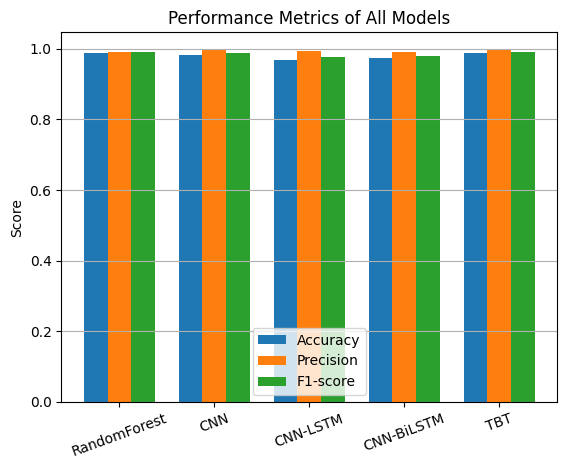

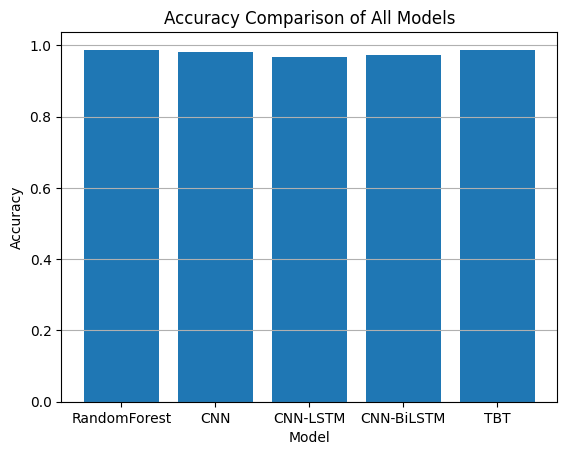

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Individual metric graphs for ALL models
# =========================

models = results["Model"].values
accuracy = results["Accuracy"].values
precision = results["Precision"].values
f1 = results["F1"].values

x = np.arange(len(models))
width = 0.25

plt.figure()
plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, precision, width, label="Precision")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, models, rotation=20)
plt.ylabel("Score")
plt.title("Performance Metrics of All Models")
plt.legend()
plt.grid(axis="y")
plt.show()


# =========================
# 2. Accuracy comparison graph (ALL models)
# =========================

plt.figure()
plt.bar(models, accuracy)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of All Models")
plt.grid(axis="y")
plt.show()


# **Front End**

In [1]:
!pip install -q streamlit pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.4 MB/s eta 0:00:00


In [2]:
%%writefile model_pipeline.py
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import BorderlineSMOTE
from tensorflow.keras import layers, models

WINDOW = 5
K = 23

def sliding_windows(df, features, window=WINDOW):
    X, y = [], []
    arr = df[features].values
    labs = df["label"].values
    for i in range(len(df) - window + 1):
        X.append(arr[i:i+window])
        y.append(int(labs[i:i+window].max() > 0))
    return np.array(X), np.array(y)

def build_cnn(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64, 3, activation="relu", padding="same")(inp)
    x = layers.Conv1D(128, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(2, activation="softmax")(x)
    return models.Model(inp, out)

def train_model(df):
    df = df.copy()

    # -----------------------------
    # 1. Separate features
    # -----------------------------
    y = df["label"]
    X = df.drop(columns=["label", "attack_cat"], errors="ignore")

    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    # -----------------------------
    # 2. Encode categorical features
    # -----------------------------
    if cat_cols:
        try:
            ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        except TypeError:
            ohe = OneHotEncoder(sparse=False, handle_unknown="ignore")

        X_cat = ohe.fit_transform(X[cat_cols])
        cat_feature_names = ohe.get_feature_names_out(cat_cols)
        X_cat = pd.DataFrame(X_cat, columns=cat_feature_names, index=X.index)
    else:
        X_cat = pd.DataFrame(index=X.index)

    # -----------------------------
    # 3. Scale numeric features
    # -----------------------------
    scaler = StandardScaler()
    X_num = pd.DataFrame(
        scaler.fit_transform(X[num_cols]),
        columns=num_cols,
        index=X.index
    )

    # -----------------------------
    # 4. Final feature matrix
    # -----------------------------
    X_final = pd.concat([X_num, X_cat], axis=1)

    # -----------------------------
    # 5. Feature selection (RF)
    # -----------------------------
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_final, y)

    topK = (
        pd.Series(rf.feature_importances_, index=X_final.columns)
        .sort_values(ascending=False)
        .head(K)
        .index.tolist()
    )

    # -----------------------------
    # 6. Sliding window
    # -----------------------------
    Xw, yw = sliding_windows(
        pd.concat([X_final[topK], y], axis=1).reset_index(drop=True),
        topK
    )

    Xw_flat = Xw.reshape(len(Xw), -1)

    # -----------------------------
    # 7. Borderline SMOTE
    # -----------------------------
    sm = BorderlineSMOTE()
    X_res, y_res = sm.fit_resample(Xw_flat, yw)
    X_res = X_res.reshape(-1, WINDOW, len(topK))

    # -----------------------------
    # 8. CNN training
    # -----------------------------
    model = build_cnn((WINDOW, len(topK)))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_res,
        y_res,
        epochs=5,
        batch_size=64,
        verbose=0
    )

    return model, scaler, topK, cat_cols, ohe

def predict_intrusion(model, scaler, features, cat_cols, ohe, df):
    df = df.copy()

    y = df["label"]
    X = df.drop(columns=["label", "attack_cat"], errors="ignore")

    X_cat = pd.DataFrame(
        ohe.transform(X[cat_cols]),
        columns=ohe.get_feature_names_out(cat_cols),
        index=X.index
    )

    X_num = pd.DataFrame(
        scaler.transform(X.drop(columns=cat_cols)),
        columns=[c for c in X.columns if c not in cat_cols],
        index=X.index
    )

    X_final = pd.concat([X_num, X_cat], axis=1)
    X_final = X_final[features]

    Xw, _ = sliding_windows(
        pd.concat([X_final, y], axis=1).reset_index(drop=True),
        features
    )

    preds = model.predict(Xw).argmax(axis=1)
    return preds.mean()


Writing model_pipeline.py


In [3]:
%%writefile app.py
import streamlit as st
import pandas as pd
from model_pipeline import train_model, predict_intrusion

DATA_PATH = "/content/UNSW_NB15_training-set.parquet"

st.set_page_config(
    page_title="Intrusion Detection System",
    layout="wide"
)

st.title("🚨 Network Intrusion Detection System (IDS)")
st.write("Dataset: **UNSW-NB15**")

# -------------------------------------------------
# LOAD BASE DATA
# -------------------------------------------------
@st.cache_data
def load_base_data():
    df = pd.read_parquet(DATA_PATH)
    if "label" not in df.columns and "attack_cat" in df.columns:
        df["label"] = (df["attack_cat"] != "Normal").astype(int)
    return df

df_base = load_base_data()

st.success("Base dataset loaded")
st.write("Base dataset shape:", df_base.shape)
st.write("Label distribution:")
st.write(df_base["label"].value_counts())

# -------------------------------------------------
# TRAIN / CACHE MODEL
# -------------------------------------------------
@st.cache_resource
def get_trained_model(df):
    return train_model(df)

# -------------------------------------------------
# SIDEBAR
# -------------------------------------------------
st.sidebar.title("⚙️ Mode Selection")

mode = st.sidebar.radio(
    "Choose Operation Mode",
    [
        "⚡ Fast Detection (Base Data)",
        "🧠 Manual Retraining (Base Data)",
        "📤 Upload File & Predict"
    ]
)

# -------------------------------------------------
# MODE 1: FAST DETECTION
# -------------------------------------------------
if mode == "⚡ Fast Detection (Base Data)":
    st.subheader("⚡ Fast Detection on Base Dataset")

    if st.button("Run Detection"):
        with st.spinner("Using cached trained model..."):
            model, scaler, features, cat_cols, ohe = get_trained_model(df_base)

        score = predict_intrusion(
            model, scaler, features, cat_cols, ohe, df_base
        )

        st.metric("🚦 Intrusion Probability", f"{score*100:.2f}%")

        if score > 0.5:
            st.error("⚠️ Intrusion Detected")
        else:
            st.success("✅ Normal Traffic")

# -------------------------------------------------
# MODE 2: MANUAL RETRAINING
# -------------------------------------------------
elif mode == "🧠 Manual Retraining (Base Data)":
    st.subheader("🧠 Manual Model Training")

    st.warning("This retrains the model from scratch and may take time.")

    if st.button("Train & Detect"):
        with st.spinner("Training CNN model..."):
            model, scaler, features, cat_cols, ohe = train_model(df_base)

        score = predict_intrusion(
            model, scaler, features, cat_cols, ohe, df_base
        )

        st.metric("🚦 Intrusion Probability", f"{score*100:.2f}%")

        if score > 0.5:
            st.error("⚠️ Intrusion Detected")
        else:
            st.success("✅ Normal Traffic")

# -------------------------------------------------
# MODE 3: UPLOAD FILE & PREDICT (FIXED)
# -------------------------------------------------
elif mode == "📤 Upload File & Predict":
    st.subheader("📤 Upload New Dataset for Intrusion Prediction")

    uploaded_file = st.file_uploader(
        "Upload UNSW-NB15 Parquet File",
        type=["parquet"]
    )

    if uploaded_file is not None:
        df_new = pd.read_parquet(uploaded_file)

        if "label" not in df_new.columns and "attack_cat" in df_new.columns:
            df_new["label"] = (df_new["attack_cat"] != "Normal").astype(int)

        st.success("Uploaded file loaded successfully")
        st.write("Uploaded dataset shape:", df_new.shape)

        if st.button("Predict Intrusion on Uploaded File"):
            with st.spinner("Predicting using trained model..."):
                model, scaler, features, cat_cols, ohe = get_trained_model(df_base)

            score = predict_intrusion(
                model, scaler, features, cat_cols, ohe, df_new
            )

            st.metric("🚦 Intrusion Probability", f"{score*100:.2f}%")

            if score > 0.5:
                st.error("⚠️ Intrusion Detected in Uploaded File")
            else:
                st.success("✅ Uploaded File is Normal")


Writing app.py


In [ ]:
!streamlit run app.py &>/content/streamlit.log &


In [4]:
from pyngrok import ngrok

ngrok.set_auth_token(
    "39EmtbGf4pyVdhRZefI4kuyEd0b_2sK7HVeRFJCxb2qAe2uJF"
)

public_url = ngrok.connect(8501)
print("🚀 Streamlit App is LIVE at:")
print(public_url)


🚀 Streamlit App is LIVE at:
NgrokTunnel: "https://farouche-quaggy-mauricio.ngrok-free.dev" -> "http://localhost:8501"
